# Modeling Hypergraphs of CS Conferences

## Model

* Let $G=(V,E)$ be a hypergraph, where $E$ is the collection of hyperedges.
* Let $H$ be the collection of admissible combinations of nodes, (e.g., if we only consider hyperedges of size less than 10). 
* $G$ is modeled as a collection of random variables ${X_h: h\in H}$.
* $X_h\sim Poisson(\lambda_h)$.
* The mean $\lambda_h$ depends on the (latent) features of nodes in $h$: $$\lambda_h=\sum_k\prod_{i\in h}r_i\theta_{ik},$$ where $\theta_{ik}$ is the percentage of node $i$ in block $k$  ($\sum_{k}\theta_{ik}=1$), and $r_i$ corresponds to the popularity of node $i$.
* Assume $X_h$'s are independent of each other given $\theta=(\theta_i)$ and $r=(r_i)$.
* The distribution of $G$ is given by $$p(G|\theta)=\prod_{h\in H} p(x_h|\theta)$$.
* Estimation: Use stochastic gradient descent to estimate $\theta$ and $r$
    * Let $\theta_{ij}=\theta_{ij}r_i$, so that we only need to deal with one set of variables $\theta$.

## Workbench

In [1]:
import time
import pandas as pd
import scipy.sparse as ssp
import numpy as np
from multiprocessing import Pool, cpu_count
from scipy.stats import dirichlet
from collections import Counter
from datetime import datetime
import random
from collections import defaultdict
from scipy.optimize import minimize
from itertools import zip_longest
from numba import guvectorize,vectorize
from numba import int64,float64,int32
from numba import cuda
import math
import pickle as pickle
from scipy.stats import pearsonr
from sklearn.metrics import precision_recall_curve
from functools import partial
from evaluate import *
import json

In [2]:
%matplotlib inline
import pylab as plt
import seaborn as sns

In [3]:
class Stopwatch:
    start_time=None
    def go(self,msg=''):
        if msg:
            print(msg, flush=True)
        self.start_time=time.time()
    def stop(self,msg=''):
        if msg:
            print("{}: {} seconds".format(msg,time.time()-self.start_time), flush=True)
        else:
            print("Elapsed time: {} seconds".format(time.time()-self.start_time), flush=True)
    def check(self):
        return time.time()-self.start_time

tic=Stopwatch()

## Load data

In [4]:
def load_date(filename):
    tic=Stopwatch()
    print("Loading paper dates %s from disk..." % filename),
    tic.go()
    pkl_file = open(filename, 'rb')
    A=pickle.load(pkl_file,encoding='latin1')
    pkl_file.close()
    tic.stop()
    return A

def load_hypergraph(filename):
    tic=Stopwatch()
    print("Loading file %s from disk..." % filename),
    tic.go()
    pkl_file = open(filename, 'rb')
    (row,col) = pickle.load(pkl_file,encoding='latin1')
    pkl_file.close()
    print(len(row), len(col))
    print(row[-1], col[-1])
    A=ssp.coo_matrix((np.ones(len(row),dtype=np.int8),(row,col)),shape=(max(row)+1, max(col)+1),dtype=np.int8)
    
    tic.stop()
    return A

In [ ]:
import os
import pandas as pd
import pickle
import numpy as np
import datasets

def load_and_save_data(input_file_path, output_file_path, split='all'):
    print(f"Loading {input_file_path}..")
    # if os.path.exists(f'../Data/{output_file_path}.pkl'):
    #     print(f"Data already exists for {output_file_path}. Skipping...")
    #     return
    
    if os.path.exists(input_file_path):
        df = pd.read_pickle(input_file_path, compression='gzip')
    elif split == 'all':
        df_train = datasets.load_dataset(input_file_path, split="train").to_pandas()
        df_test = datasets.load_dataset(input_file_path, split="test").to_pandas()
        df = pd.concat([df_train, df_test])
    else:
        df = datasets.load_dataset(input_file_path, split=split).to_pandas()
        

    # The specific AI/ML categories you want to keep
    # target_cats = {'cs.CL', 'cs.LG', 'cs.AI', 'cs.ML', 'cs.CV', 'cs.IR', 'cs.NE'}
    target_roles = ['target']

    rows, cols = [], []
    paper_id_to_id, cited_paper_to_id, corpus_to_title = {}, {}, {}
    current_cited_id, current_paper_id = 0, 0
    paper_dates = []

    print("Filtering AI/ML papers and building Citation Hypergraph")

    for index, row in df.iterrows():
        try:
            if pd.isna(row['date']):
                continue
            ts = pd.to_datetime(row['date'])
            year_month = ts.year * 12 + ts.month  # e.g., 202305
                
            
            roles = row['roles']
            if isinstance(roles, np.ndarray):
                roles = roles.tolist()
            elif not isinstance(roles, list):
                try: roles = list(roles)
                except: continue
                
            # Skip if the paper doesn't have any of the target categories
            if not roles or not any(r in target_roles for r in roles):
                continue
                
            refs = row['key_references']
            if isinstance(refs, np.ndarray):
                refs = refs.tolist()
            elif not isinstance(refs, list):
                try: refs = list(refs)
                except: continue
                    
            # if refs is None or len(refs) < 2:
            #     continue
                
            paper_id = str(row['corpus_id'])
            cited_ids = []
            for ref in refs:
                if isinstance(ref, dict) and 'corpus_id' in ref:
                    cited_ids.append(str(ref['corpus_id']))
                elif hasattr(ref, 'corpus_id'):
                    cited_ids.append(str(ref.corpus_id))
                else:
                    cited_ids.append(str(ref))
                    
            cited_ids = list(set(cited_ids))
            
            # Are you sure this is correct?
            if len(cited_ids) < 0:
                continue

            if paper_id not in paper_id_to_id:
                paper_id_to_id[paper_id] = current_paper_id
                current_paper_id += 1
                paper_dates.append(year_month)
                
            for cited_id in cited_ids:
                if cited_id not in cited_paper_to_id:
                    cited_paper_to_id[cited_id] = current_cited_id
                    current_cited_id += 1
                
                rows.append(paper_id_to_id[paper_id])
                cols.append(cited_paper_to_id[cited_id])
                
        except Exception as e:
            continue

    if len(rows) > 0:
        print(f"Built hypergraph with {len(paper_id_to_id)} AI/ML papers and {len(cited_paper_to_id)} unique cited papers.")
        
        with open(f'../Data/{output_file_path}.pkl', 'wb') as f:
            pickle.dump((rows, cols), f, protocol=pickle.HIGHEST_PROTOCOL)

        with open(f'../Data/{output_file_path}_dates.pkl', 'wb') as f:
            pickle.dump(np.array(paper_dates), f, protocol=pickle.HIGHEST_PROTOCOL)
            
        # with open(f'../Data/{output_file_path}_title_mapping.pkl', 'wb') as f:
        #     pickle.dump((paper_id_to_id, cited_paper_to_id, corpus_to_title), f, protocol=pickle.HIGHEST_PROTOCOL)
            
        print("The filtered Citation Hypergraph is ready.")
    else:
        print("No valid citations found.")
    return paper_id_to_id, cited_paper_to_id, paper_dates, corpus_to_title

In [116]:
dataset_name = 'prescience_train'
paper_id_to_id, cited_paper_to_id, paper_dates, corpus_to_title = load_and_save_data('allenai/prescience', dataset_name, split='train')

Loading allenai/prescience..
Filtering AI/ML papers and building Citation Hypergraph


KeyboardInterrupt: 

In [ ]:
df = datasets.load_dataset('allenai/prescience', split="train").to_pandas()

# transform data
target_df = df[df["roles"].apply(lambda x: "target" in x if x is not None else False)]
target_df["citation_count_1_year"] = target_df["citation_trajectory"].apply(lambda x: x[11])
target_df["num_authors"] = target_df.apply(lambda row: len(row["authors"]), axis=1)
target_df["date"] = pd.to_datetime(target_df["date"])
target_df["month"] = target_df["date"].dt.year * 12 + target_df["date"].dt.month

with open(f'~/Sci4Sci/Carrie/prescience/dataset/embeddings/train_clusters.pkl', 'wb') as f:
    clusters = pickle.load(f)

target_df["cluster_id"] = target_df["corpus_id"].map(lambda x: clusters[x])

In [70]:

G = load_hypergraph(f'../Data/{dataset_name}.pkl').tocsr()
paper_dates = load_date(f'../Data/{dataset_name}_dates.pkl')

Loading file ../Data/prescience_train.pkl from disk...
140788 140788
44989 50652
Elapsed time: 0.013399600982666016 seconds
Loading paper dates ../Data/prescience_train_dates.pkl from disk...
Elapsed time: 0.00012636184692382812 seconds


In [71]:
print(f"Matrix G shape: {G.shape}")
print(f"Number of non-zero elements (connections): {G.nnz}")
print(f"Unique dates in paper_dates: {len(set(paper_dates))}, first 10: {paper_dates[:10]}")

import numpy as np

# Sum across the rows to see how many categories each paper has
edge_sizes = G.sum(axis=1)

print(f"Mean categories per paper: {edge_sizes.mean():.2f}")
print(f"Median categories per paper: {np.median(edge_sizes)}")
print(f"MAX categories on a single paper: {edge_sizes.max()}")

# See how many papers have more than 20 categories
outliers = (edge_sizes > 20).sum()
print(f"Papers with > 20 categories: {outliers}")

Matrix G shape: (44990, 50653)
Number of non-zero elements (connections): 140788
Unique dates in paper_dates: 12, first 10: [24286 24286 24286 24286 24286 24286 24286 24286 24286 24286]
Mean categories per paper: 3.13
Median categories per paper: [[1. 1. 1. ... 3. 4. 4.]]
MAX categories on a single paper: 10
Papers with > 20 categories: 0


## Inference

In [72]:
def get_nodes(x,G):
    return tuple(sorted(G[x,:].nonzero()[1]))


# def get_nodes(e):
#     global G0
#     return tuple(sorted(G0[e,:].nonzero()[1]))
    
def get_hyperedges(G):
    # G: a edge-by-node incidence matrix
    f = partial(get_nodes,G=G)
    with Pool(cpu_count()-1) as pool:
        E=Counter(pool.map(f, (G.sum(axis=1).A.flatten()>1).nonzero()[0]))
    return E

# def get_hyperedges():
#     # G: a edge-by-node incidence matrix
#     global G0
#     x=(G0.sum(axis=1).A.flatten()>1).nonzero()[0]
#     if len(x)==0:
#         return Counter()
#     with Pool(cpu_count()-1) as pool:
#         E=Counter(pool.map(get_nodes, x))
#     return E

def batch_generator(iterable, batchsize, shuffle=False):
    if shuffle:
        iterable=list(iterable)
        random.shuffle(iterable)
    sentinel=object()
    return ([entry for entry in i if entry is not sentinel]
            for i in zip_longest(*([iter(iterable)]*batchsize), fillvalue=sentinel))

In [73]:
from numba import njit
def edges2CSR(H):
    nodes=[]
    nodes_in=[0]
    for h in H:
        nodes+=list(h)
        nodes_in.append(len(nodes))
    return nodes, nodes_in

def CSR2CSC(nodes, nodes_in, N):
    M=ssp.csr_matrix((np.ones_like(nodes,dtype=np.int8), nodes, nodes_in), shape=(len(nodes_in)-1,N))
    M=M.tocsc()
    return M.indices, M.indptr            

@vectorize([float64(float64)], target='cuda')
def copy(x):
    return x

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],int32[:],float64[:])],
             '(),    (N0,K),      (N),     (M),     (N1),    (M),     (E1),    (E),     (M),     (N1),    (M),     (E1),    (D)  ->  (D)', target='cuda')
def dtheta(x,theta,active,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,dummy,res):
    K=theta.shape[1]
    i=int(x/K)
    z=x-i*K
    res[0]=0.0
    for j in edges[edges_in[i]:edges_in[i+1]]:
        dlam=1.0
        for u in nodes[nodes_in[j]:nodes_in[j+1]]:
            if u!=i:
                dlam*=theta[active[u],z]
        p=0.0
        for k in range(K):
            prod=1.0
            for u in nodes[nodes_in[j]:nodes_in[j+1]]:
                prod*=theta[active[u],k]
            p+=prod
        p=max(p,1e-8)
        res[0]+= weights[j]*dlam/p-dlam 
            
    for j in rand_edges[rand_edges_in[i]:rand_edges_in[i+1]]:
        dlam=1.0
        for u in rand_nodes[rand_nodes_in[j]:rand_nodes_in[j+1]]:
            if u!=i:
                dlam*=theta[active[u],z]
        res[0]-=dlam

@cuda.jit
def preupdate(theta,theta0,r,s):
    x, y = cuda.grid(2)
    if x < theta.shape[0] and y < theta.shape[1]:
        theta[x,y]-=1.0/(100+r)*(theta[x,y]-theta0[x,y])/s

@cuda.jit
def update(theta,active,D,r):
    x, y = cuda.grid(2)
    if x < D.shape[0] and y < D.shape[1]:
        theta[active[x], y] += 1.0/(100+r)*D[x,y]
        cuda.atomic.max(theta, (active[x], y), 0.001)

@cuda.jit
def add_transition_gradient(D, theta_curr, theta_prev, active, sigma_sq_inv):
    """
    Add gradient of log P(Θ^t | Θ^{t-1}) to D.
    Gradient = (1/σ²) * (Θ^{t-1} - Θ^t) for active nodes.
    """
    x, y = cuda.grid(2)
    if x < D.shape[0] and y < D.shape[1]:
        idx = active[x]
        D[x, y] += sigma_sq_inv * (theta_prev[idx, y] - theta_curr[idx, y])

# Poisson likelihood calculation
@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],int32[:],float64[:])], 
             '(),    (N,K),       (N0),    (M),     (E1),    (E),      (D)  ->  (D)', target='cuda')
def p_pos(i,theta,active,nodes,nodes_in,weights,dummy,res):
    p=0.0
    K=theta.shape[1]
    for k in range(K):
        prod=1.0
        for u in nodes[nodes_in[i]:nodes_in[i+1]]:
            prod*=theta[active[u],k]
        p+=prod
    if p<1e-15:
        res[0]=0
    else:
        res[0]=weights[i]*math.log(p) - p

@guvectorize([(int64,float64[:,:],int64[:],int32[:],int32[:],int32[:],float64[:])], 
             '(),    (N,K),       (N0),    (M),     (E1),    (D)  ->  (D)', target='cuda')
def p_neg(i,theta,active,rand_nodes,rand_nodes_in,dummy,res):
    p=0.0
    K=theta.shape[1]
    for k in range(K):
        prod=1.0
        for u in rand_nodes[rand_nodes_in[i]:rand_nodes_in[i+1]]:
            prod*=theta[active[u],k]
        p+=prod
    res[0]=-p

@cuda.reduce
def sum_reduce(a, b):
    return a + b

def logPG(theta,active,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in):
    res1=p_pos(range(weights.shape[0]),theta,active,nodes,nodes_in,weights,[0])
    sum1=sum_reduce(res1.ravel())
    res2=p_neg(range(rand_nodes_in.shape[0]-1),theta,active,rand_nodes,rand_nodes_in,[0])
    sum2=sum_reduce(res2.ravel())
    return (sum1+sum2)

def estimate(G, times, K=20, thetas=None, nepochs=5, subepochs=10, batchsize=1000,
             discontinue=1, transition_sigma_init=1.0, lr_sigma=1e-4, outfile=None):
    # G: an edge-by-node incidence matrix; scipy sparse CSR matrix.
    # times: timestamp for each edge; 1D numpy array.
    # K: dimension of latent space.
    # thetas: intial values for the parameters; a list of node-by-K matrices with each matrix for a time point. If None, then the estimation starts from random matrices.
    # nepochs: number of repetitions of the whole process
    # subepochs: number of repetitions for each data point 
    # batchsize: batch size of training samples.
    # discontinue: correlation of the parameters between time points; the larger the value, the more dissimilar between time points.
    # transition_sigma_init: initial sigma for Gaussian P(Theta^t | Theta^{t-1}); learned via SGD.
    # lr_sigma: learning rate for sigma_sq in the transition density.
    
    global G0
    
    tic.go('Estimating...')
    candidate_times=np.unique(times)
    if thetas is None:
        theta=np.random.dirichlet([0.5]*K,size=G.shape[1])
        thetas=[cuda.to_device(theta)]
    else:
        if K!=thetas[0].shape[1]:
            raise("K and the dimension of initial condition don't match!")
        thetas=[thetas[0]]+thetas
        thetas=[cuda.to_device(theta) for theta in thetas]
    
    # parameters for CUDA
    threadsperblock = (32,min(32,K))
    blockspergrid_x = math.ceil(thetas[0].shape[0] / threadsperblock[0])
    blockspergrid_y = math.ceil(K / threadsperblock[1])
    blockspergrid0 = (blockspergrid_x, blockspergrid_y)
    print("Training on time points:", candidate_times)
    
    sigma_sq = np.float64(transition_sigma_init ** 2)
    
    likelihoods=[]
    for epoch in range(nepochs):
        time_index=1
        for t in candidate_times:
            if len(thetas)==time_index:
                thetas.append(copy(thetas[-1]))
            G0=G[(times==t).nonzero()[0],:]
            active_nodes=G0.sum(axis=0).A.ravel().nonzero()[0]
            G0=G0[:,active_nodes]
            G0.data=np.ones_like(G0.data)
            E0=get_hyperedges(G0)
            N=len(active_nodes)
            V=range(N)
            active_nodes=cuda.to_device(active_nodes)
            
            blockspergrid_x = math.ceil(N / threadsperblock[0])
            blockspergrid = (blockspergrid_x, blockspergrid_y)
                     
            if outfile:
                outfile.write("Epoch {} | Time: {} | Nodes: {} | Edges: {} | ".format(epoch,t,N,len(E0)))
                outfile.flush()
            
            # Evaluate the model
            for subepoch in range(subepochs):
                for batch in batch_generator(E0.items(),batchsize):
                    samples,weights=zip(*batch)
                    nodes,nodes_in=edges2CSR(samples)
                    edges,edges_in=CSR2CSC(nodes, nodes_in, N)  
                    nodes=cuda.to_device(np.array(nodes, dtype=np.int32))
                    nodes_in=cuda.to_device(np.array(nodes_in, dtype=np.int32))
                    weights=cuda.to_device(np.array(weights, dtype=np.int32))
                    edges=cuda.to_device(np.array(edges, dtype=np.int32))
                    edges_in=cuda.to_device(np.array(edges_in, dtype=np.int32))
                    E_neg=[]
                    for h in samples:
                        while True:
                            e=tuple(sorted(random.sample(V,len(h))))
                            if e not in E0:
                                E_neg.append(e)
                                break
                    rand_nodes, rand_nodes_in = edges2CSR(E_neg)
                    rand_edges, rand_edges_in = CSR2CSC(rand_nodes, rand_nodes_in, N)
                    rand_nodes=cuda.to_device(np.array(rand_nodes, dtype=np.int32))
                    rand_nodes_in=cuda.to_device(np.array(rand_nodes_in, dtype=np.int32))
                    rand_edges=cuda.to_device(np.array(rand_edges, dtype=np.int32))
                    rand_edges_in=cuda.to_device(np.array(rand_edges_in, dtype=np.int32))
                    preupdate[blockspergrid0, threadsperblock](thetas[time_index],thetas[time_index-1],(epoch+1)*(subepoch+1),discontinue)
                    # Poisson gradient
                    D=dtheta(range(N*K),thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,[0])
                    D=D.reshape(N,K)
                    
                    # Log-likelihood (Poisson term)
                    l = logPG(thetas[time_index], active_nodes, edges, edges_in, nodes, nodes_in,
                             weights, rand_edges, rand_edges_in, rand_nodes, rand_nodes_in)
                    
                    # Add Gaussian transition gradient and learn sigma_sq when we have a previous time
                    if time_index > 1:
                        theta_curr_host = thetas[time_index].copy_to_host()
                        theta_prev_host = thetas[time_index - 1].copy_to_host()
                        active_host = active_nodes.copy_to_host()
                        diff = theta_curr_host[active_host, :] - theta_prev_host[active_host, :]
                        n_active = diff.size
                        sq_diff = np.sum(diff ** 2)
                        
                        sigma_sq_inv = 1.0 / sigma_sq
                        add_transition_gradient[blockspergrid, threadsperblock](
                            D, thetas[time_index], thetas[time_index - 1],
                            active_nodes, sigma_sq_inv
                        )
                        
                        # Gradient of log P w.r.t. sigma_sq and SGD update
                        d_sigma_sq = -0.5 * n_active / sigma_sq + 0.5 * sq_diff / (sigma_sq ** 2)
                        sigma_sq = sigma_sq + lr_sigma * d_sigma_sq
                        sigma_sq = max(sigma_sq, 1e-6)
                        
                        # Add transition to log-likelihood
                        # l += -0.5 * n_active * np.log(2 * np.pi) - 0.5 * n_active * np.log(sigma_sq) - 0.5 * sq_diff / sigma_sq
                    
                    update[blockspergrid, threadsperblock](
                        thetas[time_index], active_nodes, D, (epoch+1)*(subepoch+1)
                    )
                    likelihoods.append(l / len(samples))
                    
            if outfile:
                outfile.write('log-lik: {:.2f} | Elapsed {:.2f} s\n'.format(likelihoods[-1], tic.check()))
                outfile.flush()
            time_index+=1
        thetas[0]=thetas[1]
        print(f"Loss = {l} at epoch {epoch}")
    tic.stop()
    transition_sigma_learned = np.sqrt(sigma_sq)
    print(f"Learned transition sigma = {transition_sigma_learned:.4f}")
    return (thetas[1:], likelihoods, transition_sigma_learned)

In [74]:
def estimate(G, times, K=20, thetas=None, nepochs=5, subepochs=10, batchsize=1000, discontinue=1, outfile=None):
    # G: an edge-by-node incidence matrix; scipy sparse CSR matrix.
    # times: timestamp for each edge; 1D numpy array.
    # K: dimension of latent space.
    # thetas: intial values for the parameters; a list of node-by-K matrices with each matrix for a time point. If None, then the estimation starts from random matrices.
    # nepochs: number of repetitions of the whole process
    # subepochs: number of repetitions for each data point 
    # batchsize: batch size of training samples.
    # discontinue: correlation of the parameters between time points; the larger the value, the more dissimilar between time points.
    
    global G0
    
    tic.go('Estimating...')
    candidate_times=np.unique(times)
    if thetas is None:
        theta=np.random.dirichlet([0.5]*K,size=G.shape[1])
        thetas=[cuda.to_device(theta)]
    else:
        if K!=thetas[0].shape[1]:
            raise("K and the dimension of initial condition don't match!")
        thetas=[thetas[0]]+thetas
        thetas=[cuda.to_device(theta) for theta in thetas]
    
    # parameters for CUDA
    threadsperblock = (32,min(32,K))
    blockspergrid_x = math.ceil(thetas[0].shape[0] / threadsperblock[0])
    blockspergrid_y = math.ceil(K / threadsperblock[1])
    blockspergrid0 = (blockspergrid_x, blockspergrid_y)
    
    likelihoods=[]
    for epoch in range(nepochs):
        time_index=1
        for t in candidate_times:
            if len(thetas)==time_index:
                thetas.append(copy(thetas[-1]))
            G0=G[(times==t).nonzero()[0],:]
            active_nodes=G0.sum(axis=0).A.ravel().nonzero()[0]
            G0=G0[:,active_nodes]
            G0.data=np.ones_like(G0.data)
            E0=get_hyperedges(G0)
            N=len(active_nodes)
            V=range(N)
            active_nodes=cuda.to_device(active_nodes)
            
            blockspergrid_x = math.ceil(N / threadsperblock[0])
            blockspergrid = (blockspergrid_x, blockspergrid_y)
                     
            if outfile:
                outfile.write("Epoch {} | Time: {} | Nodes: {} | Edges: {} | ".format(epoch,t,N,len(E0)))
                outfile.flush()
            
            for subepoch in range(subepochs):
                for batch in batch_generator(E0.items(),batchsize):
                    samples,weights=zip(*batch)
                    nodes,nodes_in=edges2CSR(samples)
                    edges,edges_in=CSR2CSC(nodes, nodes_in, N)  
                    nodes=cuda.to_device(np.array(nodes, dtype=np.int32))
                    nodes_in=cuda.to_device(np.array(nodes_in, dtype=np.int32))
                    weights=cuda.to_device(np.array(weights, dtype=np.int32))
                    edges=cuda.to_device(np.array(edges, dtype=np.int32))
                    edges_in=cuda.to_device(np.array(edges_in, dtype=np.int32))
                    E_neg=[]
                    for h in samples:
                        while True:
                            e=tuple(sorted(random.sample(V,len(h))))
                            if e not in E0:
                                E_neg.append(e)
                                break
                    rand_nodes, rand_nodes_in = edges2CSR(E_neg)
                    rand_edges, rand_edges_in = CSR2CSC(rand_nodes, rand_nodes_in, N)
                    rand_nodes=cuda.to_device(np.array(rand_nodes, dtype=np.int32))
                    rand_nodes_in=cuda.to_device(np.array(rand_nodes_in, dtype=np.int32))
                    rand_edges=cuda.to_device(np.array(rand_edges, dtype=np.int32))
                    rand_edges_in=cuda.to_device(np.array(rand_edges_in, dtype=np.int32))
                    preupdate[blockspergrid0, threadsperblock](thetas[time_index],thetas[time_index-1],(epoch+1)*(subepoch+1),discontinue)
                    D=dtheta(range(N*K),thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,[0])
                    D=D.reshape(N,K)      
                    update[blockspergrid, threadsperblock](thetas[time_index],active_nodes,D,(epoch+1)*(subepoch+1))        
                    l=logPG(thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in)
                    likelihoods.append(l/len(samples))
            if outfile:
                outfile.write('log-lik: {:.2f} | Elapsed {:.2f} s\n'.format(likelihoods[-1], tic.check()))
                outfile.flush()
            print(f"Loss = {l} at epoch {epoch}")
            time_index+=1
        thetas[0]=thetas[1]
    tic.stop()
    print(len(thetas))
    return (thetas[1:], likelihoods)

In [75]:
def estimate_with_gaussian_transition(G, times, K=20, thetas=None, nepochs=5, subepochs=10, batchsize=1000, discontinue=1, outfile=None):
    # G: an edge-by-node incidence matrix; scipy sparse CSR matrix.
    # times: timestamp for each edge; 1D numpy array.
    # K: dimension of latent space.
    # thetas: intial values for the parameters; a list of node-by-K matrices with each matrix for a time point. If None, then the estimation starts from random matrices.
    # nepochs: number of repetitions of the whole process
    # subepochs: number of repetitions for each data point 
    # batchsize: batch size of training samples.
    # discontinue: correlation of the parameters between time points; the larger the value, the more dissimilar between time points.
    
    global G0
    
    tic.go('Estimating...')
    candidate_times=np.unique(times)
    if thetas is None:
        theta=np.random.dirichlet([0.5]*K,size=G.shape[1])
        thetas=[cuda.to_device(theta)]
    else:
        if K!=thetas[0].shape[1]:
            raise("K and the dimension of initial condition don't match!")
        thetas=[thetas[0]]+thetas
        thetas=[cuda.to_device(theta) for theta in thetas]
    
    # parameters for CUDA
    threadsperblock = (32,min(32,K))
    blockspergrid_x = math.ceil(thetas[0].shape[0] / threadsperblock[0])
    blockspergrid_y = math.ceil(K / threadsperblock[1])
    blockspergrid0 = (blockspergrid_x, blockspergrid_y)
    
    likelihoods=[]
    for epoch in range(nepochs):
        time_index=1
        for t in candidate_times:
            if len(thetas)==time_index:
                thetas.append(copy(thetas[-1]))
            G0=G[(times==t).nonzero()[0],:]
            active_nodes=G0.sum(axis=0).A.ravel().nonzero()[0]
            G0=G0[:,active_nodes]
            G0.data=np.ones_like(G0.data)
            E0=get_hyperedges(G0)
            N=len(active_nodes)
            V=range(N)
            active_nodes=cuda.to_device(active_nodes)
            
            blockspergrid_x = math.ceil(N / threadsperblock[0])
            blockspergrid = (blockspergrid_x, blockspergrid_y)
                     
            if outfile:
                outfile.write("Epoch {} | Time: {} | Nodes: {} | Edges: {} | ".format(epoch,t,N,len(E0)))
                outfile.flush()
            
            for subepoch in range(subepochs):
                for batch in batch_generator(E0.items(),batchsize):
                    samples,weights=zip(*batch)
                    nodes,nodes_in=edges2CSR(samples)
                    edges,edges_in=CSR2CSC(nodes, nodes_in, N)  
                    nodes=cuda.to_device(np.array(nodes, dtype=np.int32))
                    nodes_in=cuda.to_device(np.array(nodes_in, dtype=np.int32))
                    weights=cuda.to_device(np.array(weights, dtype=np.int32))
                    edges=cuda.to_device(np.array(edges, dtype=np.int32))
                    edges_in=cuda.to_device(np.array(edges_in, dtype=np.int32))
                    E_neg=[]
                    for h in samples:
                        while True:
                            e=tuple(sorted(random.sample(V,len(h))))
                            if e not in E0:
                                E_neg.append(e)
                                break
                    rand_nodes, rand_nodes_in = edges2CSR(E_neg)
                    rand_edges, rand_edges_in = CSR2CSC(rand_nodes, rand_nodes_in, N)
                    rand_nodes=cuda.to_device(np.array(rand_nodes, dtype=np.int32))
                    rand_nodes_in=cuda.to_device(np.array(rand_nodes_in, dtype=np.int32))
                    rand_edges=cuda.to_device(np.array(rand_edges, dtype=np.int32))
                    rand_edges_in=cuda.to_device(np.array(rand_edges_in, dtype=np.int32))
                    preupdate[blockspergrid0, threadsperblock](thetas[time_index],thetas[time_index-1],(epoch+1)*(subepoch+1),discontinue)
                    D=dtheta(range(N*K),thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in,[0])
                    D=D.reshape(N,K)      
                    update[blockspergrid, threadsperblock](thetas[time_index],active_nodes,D,(epoch+1)*(subepoch+1))        
                    l=logPG(thetas[time_index],active_nodes,edges,edges_in,nodes,nodes_in,weights,rand_edges,rand_edges_in,rand_nodes,rand_nodes_in)
                    likelihoods.append(l/len(samples))
            if outfile:
                outfile.write('log-lik: {:.2f} | Elapsed {:.2f} s\n'.format(likelihoods[-1], tic.check()))
                outfile.flush()
            print(f"Loss = {l} at epoch {epoch}")
            time_index+=1
        thetas[0]=thetas[1]
    tic.stop()
    return (thetas[1:], likelihoods)

In [76]:
print("{}, # nodes: {} | # edges: {} | average degree: {} | average edge size: {}".format(datetime.now(),G.shape[1],G.shape[0],G.sum(axis=0).mean(),G.sum(axis=1).mean()))

2026-03-11 17:40:09.108848, # nodes: 50653 | # edges: 44990 | average degree: 2.779460249146151 | average edge size: 3.129317626139142


In [77]:
K = 20 # dimension of hidden space

In [78]:
ini_date = paper_dates[0]
final_date = paper_dates[-1]
# Then filter by time for train/test evaluation
train_mask = paper_dates <= ini_date + 6
test_mask = paper_dates > ini_date + 6

In [79]:
paper_dates[:-10]

array([24286, 24286, 24286, ..., 24297, 24297, 24297], shape=(44980,))

In [80]:
with open("output_medline_journal.txt", 'w') as logfile:
    thetas,likelihoods=estimate(G,paper_dates,K,discontinue=1.0,nepochs=5,batchsize=2000,outfile=logfile)

Estimating...


/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 15 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 3 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages

Loss = -2915.7991949097614 at epoch 0
Loss = -1223.6159827961085 at epoch 0
Loss = -473.6402776553672 at epoch 0
Loss = -4742.015111059535 at epoch 0


/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 14 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Loss = -2586.990856036087 at epoch 0


...

Loss = -1423.7298344352741 at epoch 0
Loss = -2651.527091825359 at epoch 0


/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 11 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Loss = -3351.253578239033 at epoch 0


/home/ymwan/anaconda3/envs/sci4sci/lib/python3.10/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 6 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


Loss = -1699.6437754864228 at epoch 0
Loss = -313.1361938600373 at epoch 0
Loss = -956.8772117744929 at epoch 0
Loss = -2019.2097735447092 at epoch 1
Loss = -943.5554334241671 at epoch 1
Loss = -385.6529268766656 at epoch 1
Loss = -4019.7694642174874 at epoch 1
Loss = -2104.240201143973 at epoch 1
Loss = -2344.85721030049 at epoch 1
Loss = -1168.5007253406663 at epoch 1
Loss = -2183.934584003153 at epoch 1
Loss = -2781.559770627628 at epoch 1
Loss = -1412.2926022045763 at epoch 1
Loss = -260.1404288870651 at epoch 1
Loss = -802.0844504628981 at epoch 1
Loss = -35054.39064865619 at epoch 2
Loss = -833.1350278608368 at epoch 2
Loss = -333.768970784956 at epoch 2
Loss = -3185.1176245977463 at epoch 2
Loss = -1891.0559871042549 at epoch 2
Loss = -2110.4341528684267 at epoch 2
Loss = -1058.2320860487318 at epoch 2
Loss = -1962.4116996892403 at epoch 2
Loss = -2545.072049284392 at epoch 2
Loss = -1279.5905122445674 at epoch 2
Loss = -238.78302107825937 at epoch 2
Loss = -731.4801604567701 at

In [81]:
thetas[0]

In [82]:
thetas=[theta.copy_to_host() for theta in thetas]

In [83]:
with open('./Fitted_Model/block_model_cs_journal2.pkl','wb') as outfile2:
    pickle.dump([thetas,likelihoods,np.unique(paper_dates)],outfile2)

In [84]:
get_hyperedges(G)

Counter({(np.int32(38), np.int32(485)): 8,
         (np.int32(269), np.int32(608)): 7,
         (np.int32(608), np.int32(1039)): 7,
         (np.int32(37), np.int32(38)): 6,
         (np.int32(1411), np.int32(3713)): 6,
         (np.int32(40), np.int32(3233)): 6,
         (np.int32(567), np.int32(1378)): 5,
         (np.int32(1521), np.int32(2315)): 5,
         (np.int32(38), np.int32(563)): 5,
         (np.int32(40), np.int32(128)): 5,
         (np.int32(127), np.int32(128)): 5,
         (np.int32(297), np.int32(1090)): 4,
         (np.int32(38), np.int32(128)): 4,
         (np.int32(769), np.int32(2205)): 4,
         (np.int32(248), np.int32(3975)): 4,
         (np.int32(37), np.int32(64)): 4,
         (np.int32(11), np.int32(802)): 4,
         (np.int32(3975), np.int32(6969)): 4,
         (np.int32(38), np.int32(411)): 4,
         (np.int32(136), np.int32(137)): 4,
         (np.int32(38), np.int32(6734)): 4,
         (np.int32(135), np.int32(136), np.int32(137)): 4,
         (np.int

## Evaluation

In [85]:
with open('./Fitted_Model/block_model_cs_journal2.pkl','rb') as infile:
    loaded=pickle.load(infile)
    thetas,likelihoods,times=loaded[0],loaded[1],loaded[2]
    transition_sigma=loaded[3] if len(loaded)>3 else None

In [86]:
thetas[0].shape

(50653, 20)

In [87]:
from evaluate import *

In [88]:
def estimate_auc(theta, E, N, iterations=10, batchsize=1000):
    auc=np.zeros(iterations)
    batchsize2=min(batchsize,len(E))
    for i in range(iterations):
        E0=random.sample(E.keys(),batchsize2)
        l_pos=np.zeros(batchsize2)
        l_neg=np.zeros(batchsize2)
        for j,h in enumerate(E0):
            l_pos[j]=ph(h,theta)
            while True:
                e=tuple(sorted(random.sample(range(N),len(h))))
                if e not in E:
                    break
            l_neg[j]=ph(e,theta)
        auc[i] = (l_pos>=l_neg).sum()/batchsize2
    return (auc.mean(), auc.std())

In [89]:
def evaluate(G, edge_time, thetas):
    time=[]
    num_nodes=[]
    num_edges=[]
    mean_degree=[]
    mean_edge_size=[]
    max_edge_size=[]
    repeated_edges=[]
    prev_E=None
    AUC=[]
    std_AUC=[]
    for i,t in enumerate(np.unique(edge_time)[:-1]):
        print("Evaluating time {}...".format(t+1))
        # Get hyperedges at t
        print((edge_time==t+1).nonzero()[0])
        G0=G[(edge_time==t+1).nonzero()[0],:]
        E0=get_hyperedges(G0)
        if len(E0)==0:
            print("No data found.")
            continue
        # Basic statistics
        degree=G0.sum(axis=0).A.squeeze()
        degree=degree[degree>0]
        time.append(t+1)
        num_nodes.append(len(degree))
        num_edges.append(len(E0))
        mean_edge_size.append(np.mean([len(h) for h in E0]))
        max_edge_size.append(max(len(h) for h in E0))
        mean_degree.append(degree.mean())
        # Calculate AUC
        auc,std=estimate_auc(thetas[i], 
                             E0, 
                             G0.shape[1],
                             iterations=10, 
                             batchsize=1000)
        AUC.append(auc)
        std_AUC.append(std)
        # Count repeated edges from previous years
        if not prev_E:
            G0=G[(edge_time==t).nonzero()[0],:]
            prev_E=set(list(get_hyperedges(G0).keys()))
        curr_E = set(list(E0.keys()))
        print(curr_E)
        repeated_edges.append(len(curr_E & prev_E))
        print("len(prev_E)", len(prev_E), "len(curr_E)", len(curr_E), "repeated_edges[-1]", repeated_edges[-1])
        prev_E = curr_E

    res = pd.DataFrame({"time": time,
                        "num_nodes": num_nodes,
                        "num_edges": num_edges,
                        "mean_edge_size": mean_edge_size,
                        "max_edge_size": max_edge_size,
                        "mean_degree": mean_degree,
                        "auc": AUC,
                        "auc_std": std_AUC,
                        "repeated_edges": repeated_edges})
    print(res)
    return res



In [90]:
#load_and_save_data('allenai/prescience', 'prescience_test', split='test')

In [91]:
test_G = load_hypergraph('../Data/prescience_test.pkl').tocsr()
test_paper_dates = load_date('../Data/prescience_test_dates.pkl')

Loading file ../Data/prescience_test.pkl from disk...
160495 160495
52835 58878
Elapsed time: 0.016217947006225586 seconds
Loading paper dates ../Data/prescience_test_dates.pkl from disk...
Elapsed time: 0.00014972686767578125 seconds


In [92]:
len(thetas)

12

In [93]:
# Estimate the model on test set 202401~202412
# AUC gives the prediction of number of papers corresponds to the top references
res = evaluate(G, paper_dates, thetas)

Evaluating time 24287...
[4031 4032 4033 ... 7404 7405 7406]


/tmp/ipykernel_3507087/3186122600.py:5: DeprecationWarning: Sampling from a set deprecated
since Python 3.9 and will be removed in a subsequent version.
  E0=random.sample(E.keys(),batchsize2)


{(np.int32(127), np.int32(4773), np.int32(6191), np.int32(9082), np.int32(9083), np.int32(9084)), (np.int32(66), np.int32(1186), np.int32(2883), np.int32(6323)), (np.int32(128), np.int32(563)), (np.int32(27), np.int32(29), np.int32(30), np.int32(10628), np.int32(10629)), (np.int32(1334), np.int32(5029), np.int32(11498)), (np.int32(16), np.int32(17), np.int32(268), np.int32(13733), np.int32(13734)), (np.int32(1177), np.int32(13146), np.int32(13147)), (np.int32(8796), np.int32(10428)), (np.int32(137), np.int32(3128)), (np.int32(128), np.int32(409), np.int32(539), np.int32(1771), np.int32(7441), np.int32(9952), np.int32(10552)), (np.int32(10611), np.int32(10612)), (np.int32(1446), np.int32(1458), np.int32(7511)), (np.int32(454), np.int32(12863)), (np.int32(1411), np.int32(3711), np.int32(5132)), (np.int32(2301), np.int32(12505)), (np.int32(81), np.int32(84), np.int32(2098), np.int32(3138), np.int32(11234), np.int32(11235), np.int32(11236), np.int32(11237), np.int32(11238)), (np.int32(2853

In [94]:
res.head(20)

,time,num_nodes,num_edges,mean_edge_size,max_edge_size,mean_degree,auc,auc_std,repeated_edges
0,24287,7207,2435,3.976591,10,1.474539,0.7882,0.010562,5
1,24288,6487,2174,3.974241,10,1.470479,0.8026,0.009013,4
2,24289,5918,1885,3.865252,10,1.367185,0.7868,0.014531,6
3,24290,8478,3019,3.946009,10,1.532437,0.8047,0.007100,5
4,24291,9267,3250,4.059692,10,1.542678,0.8026,0.013879,10
5,24292,7878,2604,3.949309,10,1.439706,0.7973,0.009623,8
6,24293,9184,3193,3.955528,10,1.499020,0.7817,0.011073,6
7,24294,9696,3499,3.967419,10,1.561675,0.8008,0.007935,11
8,24295,8431,2787,3.985648,10,1.455818,0.7921,0.008780,5
9,24296,6570,2143,3.791414,10,1.382648,0.7696,0.013017,4


In [95]:
res.to_csv("./Results/cs_journal_evaluation2.csv", index=False)

In [96]:
res['frac_repeated']=res["repeated_edges"]/res["num_edges"]

In [97]:
df = res.copy()
unique_times = sorted(df['time'].dropna().unique())
time_to_int = {t: i for i, t in enumerate(unique_times)}
df['time_int'] = df['time'].map(time_to_int)

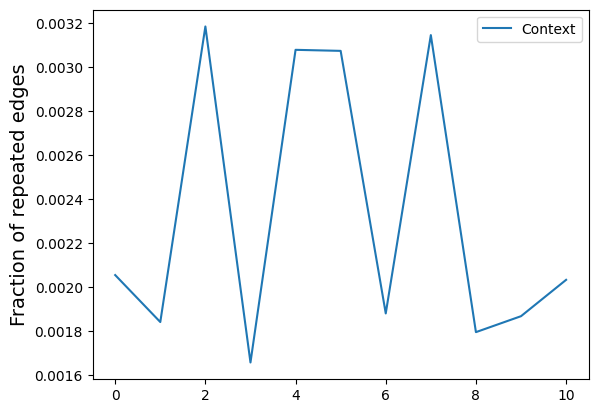

In [98]:
plt.plot(df["time_int"], df["frac_repeated"], label="Context")
plt.ylabel("Fraction of repeated edges", fontsize=14)
plt.legend()

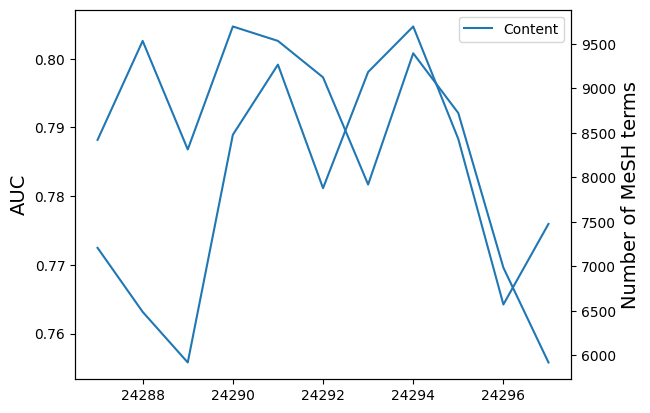

In [99]:
plt.plot(df["time"], df["auc"], label="MeSH");
ax = plt.gca();
ax2 = ax.twinx()
ax2.plot(df["time"], df["num_nodes"], label="Content")
ax.set_ylabel("AUC", fontsize=14);
ax2.set_ylabel("Number of MeSH terms", fontsize=14);
plt.legend();

In [100]:
# Evaluate train
res_train, prev_E = evaluate(G, paper_dates[train_mask], thetas_train)

# Evaluate test with train history
res_test, _ = evaluate(G, paper_dates[test_mask], thetas_test, prev_E_init=prev_E)

NameError: name 'thetas_train' is not defined

In [118]:
import numpy as np
from collections import Counter
import pickle

paper_dates_list = paper_dates

print("Loading title mappings")
with open('../Data/title_mapping.pkl', 'rb') as f:
    id_to_cited_paper, _ = pickle.load(f)


print("THE MOST REPEATED CITATION CLUSTER BY YEAR ")

unique_years = sorted(np.unique(paper_dates))

for target_year in unique_years:
    G_year = G[(paper_dates == target_year).nonzero()[0], :]
    
    edges_list = []
    for i in range(G_year.shape[0]):
        cited_nodes = tuple(sorted(G_year.indices[G_year.indptr[i]:G_year.indptr[i+1]]))
        if len(cited_nodes) >= 2:
            edges_list.append(cited_nodes)
            
    # Count them up
    edge_counts = Counter(edges_list)
    top_edges = edge_counts.most_common(1) 
    
    if top_edges and top_edges[0][1] > 1:
        edge, count = top_edges[0]
        print(f"\nYEAR: {target_year} | Cited together {count} times")
        
        # Translate the IDs to Titles
        for node_id in edge:
            corpus_id = id_to_cited_paper.get(node_id, "Unknown ID")
            title = corpus_to_title.get(str(corpus_id), "Title not found in dataset")
            print(f"  - {title}")
    else:
        print(f"\n YEAR: {target_year} | No exact repeated citation clusters this year.")

Loading title mappings
THE MOST REPEATED CITATION CLUSTER BY YEAR 

YEAR: 24286 | Cited together 2 times
  - ('RoFormer: Enhanced Transformer with Rotary Position Embedding', None)
  - ('Extending Context Window of Large Language Models via Positional Interpolation', None)

YEAR: 24287 | Cited together 2 times
  - ('BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding', None)
  - ('Chinese Open Instruction Generalist: A Preliminary Release', None)

YEAR: 24288 | Cited together 3 times
  - ('ImageNet Large Scale Visual Recognition Challenge', None)
  - ('What makes fake images detectable? Understanding properties that generalize', None)

YEAR: 24289 | Cited together 2 times
  - ('Multi-Grained Vision Language Pre-Training: Aligning Texts with Visual Concepts', None)
  - ('A Transformer-Based Feature Segmentation and Region Alignment Method For UAV-View Geo-Localization', None)
  - ('Each Part Matters: Local Patterns Facilitate Cross-view Geo-localization', No

In [119]:

import pandas as pd
import numpy as np
from collections import defaultdict
import pickle
from IPython.display import display

def decode_month(time_step):
    year = (time_step - 1) // 12
    month = ((time_step - 1) % 12) + 1
    return f"{month:02d}-{year}"

print("Loading title mappings...")
with open('../Data/title_mapping.pkl', 'rb') as f:
    id_to_cited_paper, _ = pickle.load(f)

id_to_citing_paper = {v: k for k, v in paper_id_to_id.items()}

unique_months = sorted(np.unique(paper_dates_list))
table_data = []

for target_month in unique_months:
    readable_date = decode_month(target_month)
    
    month_paper_indices = (np.array(paper_dates_list) == target_month).nonzero()[0]
    G_month = G[month_paper_indices, :]
    
    edge_to_papers = defaultdict(list)
    
    for i in range(G_month.shape[0]):
        cited_nodes = tuple(sorted(G_month.indices[G_month.indptr[i]:G_month.indptr[i+1]]))
        
        if len(cited_nodes) >= 2:
            original_row_idx = month_paper_indices[i]
            edge_to_papers[cited_nodes].append(original_row_idx)
            
    if not edge_to_papers:
        continue
        
    top_edge, citing_papers = max(edge_to_papers.items(), key=lambda x: len(x[1]))
    count = len(citing_papers)
    
    if count > 1:
        # Format the foundational papers as a bulleted string
        foundation_titles = []
        for node_id in top_edge:
            corpus_id = id_to_cited_paper.get(node_id, "Unknown ID")
            title = corpus_to_title.get(str(corpus_id), f"Title not found for {corpus_id}")
            foundation_titles.append(f"- {title}")
        foundation_str = "\n".join(foundation_titles)
        
        # Format the citing papers as a bulleted string (up to 3 examples)
        citing_titles = []
        for row_idx in citing_papers:
            corpus_id = id_to_citing_paper.get(row_idx, "Unknown ID")
            title = corpus_to_title.get(str(corpus_id), f"Title not found for {corpus_id}")
            citing_titles.append(f"- {title}")
        citing_str = "\n".join(citing_titles)
        
        # Append as a row to our table data
        table_data.append({
            "Month": readable_date,
            "Repeats": count,
            "The Foundation (Cited Papers)": foundation_str,
            "Cited By (New Papers)": citing_str
        })

# Convert to a DataFrame
slide_df = pd.DataFrame(table_data)

# Display the last 10 months with styling so the line breaks render perfectly
print("\nMost Repeated Citation Clusters:")
styled_table = slide_df.tail(10).style.set_properties(**{
    'white-space': 'pre-wrap', 
    'text-align': 'left',
    'vertical-align': 'top'
})
display(styled_table)

Loading title mappings...

Most Repeated Citation Clusters:


,Month,Repeats,The Foundation (Cited Papers),Cited By (New Papers)
1,11-2023,2,"- ('BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding', None) - ('Chinese Open Instruction Generalist: A Preliminary Release', None)","- ('XplainLLM: A Knowledge-Augmented Dataset for Reliable Grounded Explanations in LLMs', np.int64(0)) - ('Towards Real-World Writing Assistance: A Chinese Character Checking Benchmark with Faked and Misspelled Characters', np.int64(7))"
2,12-2023,3,"- ('ImageNet Large Scale Visual Recognition Challenge', None) - ('What makes fake images detectable? Understanding properties that generalize', None)","- ('Resolution Chromatography of Diffusion Models', np.int64(1)) - ('Lecture Notes in Probabilistic Diffusion Models', np.int64(0)) - ('Unraveling the Temporal Dynamics of the Unet in Diffusion Models', np.int64(1))"
3,01-2024,2,"- ('Multi-Grained Vision Language Pre-Training: Aligning Texts with Visual Concepts', None) - ('A Transformer-Based Feature Segmentation and Region Alignment Method For UAV-View Geo-Localization', None) - ('Each Part Matters: Local Patterns Facilitate Cross-view Geo-localization', None)","- ('A Transformer-Based Adaptive Semantic Aggregation Method for UAV Visual Geo-Localization', np.int64(0)) - ('View Distribution Alignment with Progressive Adversarial Learning for UAV Visual Geo-Localization', np.int64(1))"
4,02-2024,3,"- ('BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding', None) - ('Answer-based Adversarial Training for Generating Clarification Questions', None)","- ('Efficient Models for the Detection of Hate, Abuse and Profanity', np.int64(0)) - ('Enhancing EEG-to-Text Decoding through Transferable Representations from Pre-trained Contrastive EEG-Text Masked Autoencoder', np.int64(4)) - ('FairBelief -- Assessing Harmful Beliefs in Language Models', np.int64(0))"
5,03-2024,2,"- ('Learning Phrase Representations using RNN Encoder-Decoder for Statistical Machine Translation', None) - ('Bi-directional Training for Composed Image Retrieval via Text Prompt Learning', None) - ('Zero-Shot Composed Image Retrieval with Textual Inversion', None)","- ('Image2Sentence based Asymmetrical Zero-shot Composed Image Retrieval', np.int64(3)) - ('Knowledge-Enhanced Dual-stream Zero-shot Composed Image Retrieval', np.int64(12))"
6,05-2024,2,"- ('Free View Synthesis', None) - ('Point-E: A System for Generating 3D Point Clouds from Complex Prompts', None)","- ('Spectrally Pruned Gaussian Fields with Neural Compensation', np.int64(14)) - ('Reducing the Memory Footprint of 3D Gaussian Splatting', np.int64(52))"
7,06-2024,2,"- ('Last Layer Re-Training is Sufficient for Robustness to Spurious Correlations', None) - ('Kernelized Concept Erasure', None)","- ('Applying Intrinsic Debiasing on Downstream Tasks: Challenges and Considerations for Machine Translation', np.int64(1)) - ('On the Encoding of Gender in Transformer-based ASR Representations', np.int64(4))"
8,07-2024,2,"- ('When the Umpire is also a Player: Bias in Private Label Product Recommendations on E-commerce Marketplaces', None) - ('Addressing Marketing Bias in Product Recommendations', None)","- ('Investigating Nudges toward Related Sellers on E-commerce Marketplaces: A Case Study on Amazon', np.int64(3)) - ('Auditing the Grid-Based Placement of Private Label Products on E-commerce Search Result Pages', np.int64(0))"
9,08-2024,2,"- ('ViT2EEG: Leveraging Hybrid Pretrained Vision Transformers for EEG Data', None) - ('EEGEyeNet: a Simultaneous Electroencephalography and Eye-tracking Dataset and Benchmark for Eye Movement Prediction', None)","- ('Effect of Kernel Size on CNN-Vision-Transformer-Based Gaze Prediction Using Electroencephalography Data', np.int64(0)) - ('Advancing EEG-Based Gaze Prediction Using Depthwise Separable Convolution and Enhanced Pre-Processing', np.int64(17))"
10,09-2024,2,"- ('Swin-Unet: Unet-like Pure Transformer for Medical Image Segmentation', None) - ('Ensemble deep l

In [ ]:
# load data
def default_edge_feature_extractor(edge_dict):
    return [1]


df = datasets.load_dataset("allenai/prescience", split="train").to_pandas()


In [ ]:

# transform data
target_df = df[df["roles"].apply(lambda x: "target" in x if x is not None else False)]
target_df["citation_count_1_year"] = target_df["citation_trajectory"].apply(lambda x: x[11])
target_df["num_authors"] = target_df.apply(lambda row: len(row["authors"]), axis=1)
target_df["date"] = pd.to_datetime(target_df["date"])
target_df["month"] = target_df["date"].dt.year * 12 + target_df["date"].dt.month


# keep only top references
num_top_references = 100
all_references = target_df["key_references"].apply(lambda x: x).explode().tolist()

print(len(all_references))
# deduplicate
dedup_references = {d["corpus_id"]: d for d in all_references}.values()
print(len(all_references))
# sort by num_citations descending
top_references = sorted(dedup_references, key=lambda x: x["num_citations"], reverse=True)[:num_top_references]
print(top_references[:10], top_references[-10:])


target_df["top_references"] = target_df["key_references"].apply(lambda x: [ref for ref in x if ref in top_references])

# TODO: build edge features
target_df["edge_features"] = target_df.apply(lambda x: default_edge_feature_extractor(x["top_references"]), axis=1)




/tmp/ipykernel_3507087/4044938084.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df["citation_count_1_year"] = target_df["citation_trajectory"].apply(lambda x: x[11])
/tmp/ipykernel_3507087/4044938084.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df["num_authors"] = target_df.apply(lambda row: len(row["authors"]), axis=1)
/tmp/ipykernel_3507087/4044938084.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

140788
140788
[{'corpus_id': '6628106', 'num_citations': 139213.0}, {'corpus_id': '13756489', 'num_citations': 104018.0}, {'corpus_id': '14124313', 'num_citations': 92416.0}, {'corpus_id': '52967399', 'num_citations': 80994.0}, {'corpus_id': '10659969', 'num_citations': 68701.0}, {'corpus_id': '3719281', 'num_citations': 66082.0}, {'corpus_id': '88513115', 'num_citations': 59972.0}, {'corpus_id': '10328909', 'num_citations': 55287.0}, {'corpus_id': '206592484', 'num_citations': 40733.0}, {'corpus_id': '5808102', 'num_citations': 40413.0}] [{'corpus_id': '3264198', 'num_citations': 9894.0}, {'corpus_id': '211227', 'num_citations': 9746.0}, {'corpus_id': '207238980', 'num_citations': 9721.0}, {'corpus_id': '6447277', 'num_citations': 9443.0}, {'corpus_id': '12803511', 'num_citations': 9441.0}, {'corpus_id': '980236', 'num_citations': 9418.0}, {'corpus_id': '1055111', 'num_citations': 9393.0}, {'corpus_id': '8485068', 'num_citations': 9327.0}, {'corpus_id': '1745976', 'num_citations': 924

/tmp/ipykernel_3507087/4044938084.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df["top_references"] = target_df["key_references"].apply(lambda x: [ref for ref in x if ref in top_references])
/tmp/ipykernel_3507087/4044938084.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_df["edge_features"] = target_df.apply(lambda x: default_edge_feature_extractor(x["top_references"]), axis=1)


In [ ]:
target_df.head()

,corpus_id,arxiv_id,date,title,abstract,categories,roles,key_references,authors,citation_trajectory,citation_count_1_year,num_authors,month,top_references,edge_features
301079,263334020,2310.00749,2023-10-01,SEED: Domain-Specific Data Curation With Large...,Data curation tasks that prepare data for anal...,"[cs.DB, cs.LG]","[target, target.author.publication_history, ta...","[{'corpus_id': '248965029', 'num_citations': 4...","[{'author_id': 'z chen_21', 'name': 'Zui Chen'...","[0, 0, 0, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, ...",3,10,24286,[],[1]
301080,263334340,2310.00664,2023-10-01,Twin Neural Network Improved k-Nearest Neighbo...,Twin neural network regression is trained to p...,[cs.LG],[target],"[{'corpus_id': '229923810', 'num_citations': 2...","[{'author_id': 's wetzel_1', 'name': 'Sebastia...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,1,24286,[],[1]
301082,263605418,2310.00808,2023-10-01,Completing Visual Objects via Bridging Generat...,This paper presents a novel approach to object...,[cs.CV],"[target, target.author.publication_history]","[{'corpus_id': '232307022', 'num_citations': 1...","[{'author_id': 'x li_350', 'name': 'Xiang Li',...","[0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 3, 3, 3, 3, 3, ...",3,6,24286,[],[1]
301083,263608648,2310.01444,2023-10-01,Adapting LLM Agents with Universal Feedback in...,Recent advances in large language models (LLMs...,"[cs.CL, cs.AI]","[target, target.author.publication_history]","[{'corpus_id': '246411621', 'num_citations': 1...","[{'author_id': 'k wang_9', 'name': 'Kuan Wang'...","[0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 3, 4, 4, 4, ...",3,6,24286,[],[1]
301086,263334162,2310.00646,2023-10-01,Source Attribution for Large Language Model-Ge...,The impressive performances of Large Language ...,"[cs.LG, cs.AI, stat.ML]","[target, target.author.publication_history, ta...","[{'corpus_id': '141496572', 'num_citations': 6...","[{'author_id': 'j wang_392', 'name': 'Jingtan ...","[0, 0, 1, 1, 1, 2, 2, 2, 3, 4, 5, 5, 8, 9, 9, ...",5,7,24286,[],[1]


In [ ]:
top_references_df = pd.DataFrame(top_references)
top_references_df = df.merge(top_references_df, left_on="corpus_id", right_on="corpus_id", how="right")
top_references_df.sort_values(by="num_citations", ascending=False, inplace=True)
top_references_df.head()

,corpus_id,arxiv_id,date,title,abstract,categories,roles,key_references,authors,citation_trajectory,num_citations
0,6628106,1412.6980,2014-12-22,Adam: A Method for Stochastic Optimization,"We introduce Adam, an algorithm for first-orde...",[cs.LG],"[target.author.publication_history, target.aut...","[{'corpus_id': '216078090', 'num_citations': N...","[{'author_id': 'd kingma_1', 'name': 'Diederik...",None,139213.0
1,13756489,1706.03762,2017-06-12,Attention Is All You Need,The dominant sequence transduction models are ...,"[cs.CL, cs.LG]","[target.author.publication_history, target.aut...","[{'corpus_id': '3603249', 'num_citations': Non...","[{'author_id': 'a vaswani_1', 'name': 'Ashish ...",None,104018.0
2,14124313,1409.1556,2014-09-04,Very Deep Convolutional Networks for Large-Sca...,In this work we investigate the effect of the ...,[cs.CV],[target.author.publication_history.key_referen...,None,None,None,92416.0
3,52967399,1810.04805,2018-10-11,BERT: Pre-training of Deep Bidirectional Trans...,We introduce a new language representation mod...,[cs.CL],"[target.author.publication_history, target.aut...","[{'corpus_id': '3432876', 'num_citations': Non...","[{'author_id': 'j devlin_1', 'name': 'Jacob De...",None,80994.0
4,10659969,1201.0490,2012-01-02,Scikit-learn: Machine Learning in Python,Scikit-learn is a Python module integrating a ...,"[cs.LG, cs.MS]","[target.author.publication_history, target.aut...",[],"[{'author_id': 'f pedregosa_1', 'name': 'Fabia...",None,68701.0


In [ ]:

target_df_filtered = target_df[target_df["top_references"].apply(lambda x: len(x) > 0)]

print(target_df["citation_count_1_year"].describe())
print(target_df_filtered["citation_count_1_year"].describe())



count    44990.000000
mean         5.528495
std         18.080780
min          0.000000
25%          0.000000
50%          2.000000
75%          5.000000
max       1132.000000
Name: citation_count_1_year, dtype: float64
count    119.000000
mean       2.831933
std        4.983565
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max       31.000000
Name: citation_count_1_year, dtype: float64


In [ ]:
# Add a new column to have all the references of target papers

# In edge features, the references in key_references get weight 5 and the rest get weight 1

# maybe don't need to do this, just use the top_references_df
